# Tutorial de NetworkX para modelos de redes

Resolución de problemas clásicos de redes: MST, Ruta Más Corta y Flujo Máximo

---

## Instalación y configuración inicial

Antes de empezar, necesitamos instalar las librerías. networkx es la librería principal para trabajar con grafos, matplotlib nos sirve para dibujarlos y numpy para operaciones numéricas auxiliares.

```bash
pip install networkx matplotlib numpy
```

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import networkx as nx          # Librería principal para grafos
import matplotlib.pyplot as plt # Para dibujar las redes
import numpy as np              # Utilidades numéricas

# Configuramos el tamaño y estilo de las figuras para que se vean bien
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

¿Por qué usar NetworkX? Porque implementa los algoritmos clásicos de teoría de grafos (Dijkstra, Kruskal, Ford-Fulkerson, etc.) en una sola línea, evitando tener que programarlos desde cero.

## Árbol de Expansión Mínima (MST)

### Formulación matemática
---
Dado un grafo no dirigido $G=(V,E)$ con pesos $w_{ij} \ge 0$, el árbol de expansión mínima es un subconjunto $T \subseteq E$ que:

* Conecta todos los nodos (expansión).
* No contiene ciclos (es un árbol).
* Minimiza la suma de pesos:

$$\min \sum_{(i,j) \in T} w_{ij}$$

Observación importante: La red de la imagen 1 es dirigida, pero el MST requiere un grafo no dirigido. Cuando existen dos arcos opuestos entre el mismo par de nodos (ej. $2 \to 6$ con peso 6 y $6 \to 2$ con peso 7), conservamos el menor peso al convertir a no dirigido.

### Definición de la red
---

In [2]:
# ============================================================
# PASO 1: Definir los arcos dirigidos originales de la Imagen 1
# ============================================================
# Cada tupla tiene la forma: (nodo_origen, nodo_destino, peso)
edges_G1 = [
    # Desde el nodo 1
    (1, 2, 5), (1, 3, 1),
    # Desde el nodo 2
    (2, 3, 2), (2, 6, 6), (2, 4, 7), (2, 5, 1),
    # Desde el nodo 6 hacia 2 (arco opuesto al anterior)
    (6, 2, 7),
    # Desde el nodo 3
    (3, 4, 6), (3, 5, 7),
    # Desde el nodo 4
    (4, 3, 7), (4, 6, 4), (4, 7, 6), (4, 5, 3),
    # Desde el nodo 5
    (5, 6, 5), (5, 7, 9),
    # Desde el nodo 6
    (6, 7, 2)
]

# ============================================================
# PASO 2: Convertir a grafo NO dirigido conservando el menor peso
# ============================================================
# nx.Graph() crea un grafo NO dirigido (las aristas no tienen dirección)
G1_und = nx.Graph()

# Recorremos cada arco dirigido de la lista
for u, v, w in edges_G1:
    # Si ya existe una arista entre u y v (en cualquier sentido), 
    # nos quedamos con el MENOR peso porque en un grafo no dirigido
    # u--v es la misma arista que v--u
    if G1_und.has_edge(u, v):
        G1_und[u][v]['weight'] = min(G1_und[u][v]['weight'], w)
    else:
        # Si no existe, la creamos con su peso
        G1_und.add_edge(u, v, weight=w)

# Verificamos cómo quedó el grafo
print("Nodos:", list(G1_und.nodes()))
print("Aristas:", list(G1_und.edges(data='weight')))

Nodos: [1, 2, 3, 6, 4, 5, 7]
Aristas: [(1, 2, 5), (1, 3, 1), (2, 3, 2), (2, 6, 6), (2, 4, 7), (2, 5, 1), (3, 4, 6), (3, 5, 7), (6, 4, 4), (6, 5, 5), (6, 7, 2), (4, 7, 6), (4, 5, 3), (5, 7, 9)]


### Cálculo del MST con el algoritmo de Kruskal
---

In [3]:
# ============================================================
# PASO 3: Calcular el Árbol de Expansión Mínima
# ============================================================
# nx.minimum_spanning_tree() aplica Kruskal o Prim.
# Parámetros:
#   - G: el grafo no dirigido
#   - algorithm: 'kruskal' (ordena aristas por peso) o 'prim' (crece desde un nodo)
#   - weight: el atributo que contiene el peso ('weight' por defecto)
mst = nx.minimum_spanning_tree(G1_und, algorithm='kruskal')

# G.size(weight='weight') suma todos los pesos de las aristas del grafo
peso_total = mst.size(weight='weight')

print(f"Peso total del MST: {peso_total}")
print("Aristas del MST:")
# .edges(data=True) devuelve (u, v, diccionario_de_atributos)
for u, v, d in mst.edges(data=True):
    print(f"  {u} -- {v}  (peso = {d['weight']})")

Peso total del MST: 13.0
Aristas del MST:
  1 -- 3  (peso = 1)
  2 -- 5  (peso = 1)
  2 -- 3  (peso = 2)
  6 -- 7  (peso = 2)
  6 -- 4  (peso = 4)
  4 -- 5  (peso = 3)



Salida esperada:

```
Peso total del MST: 13
Aristas del MST:
  1 -- 3  (peso = 1)
  2 -- 5  (peso = 1)
  2 -- 3  (peso = 2)
  6 -- 7  (peso = 2)
  4 -- 5  (peso = 3)
  4 -- 6  (peso = 4)
```

¿Por qué Kruskal elige estas aristas? Ordena TODAS las aristas por peso ascendente y las va agregando si no forman ciclo. Los pesos más pequeños son 1, 1, 2, 2, 3, 4 → y con ellos ya se conectan los 7 nodos sin ciclos.

### Dibujo del MST
---

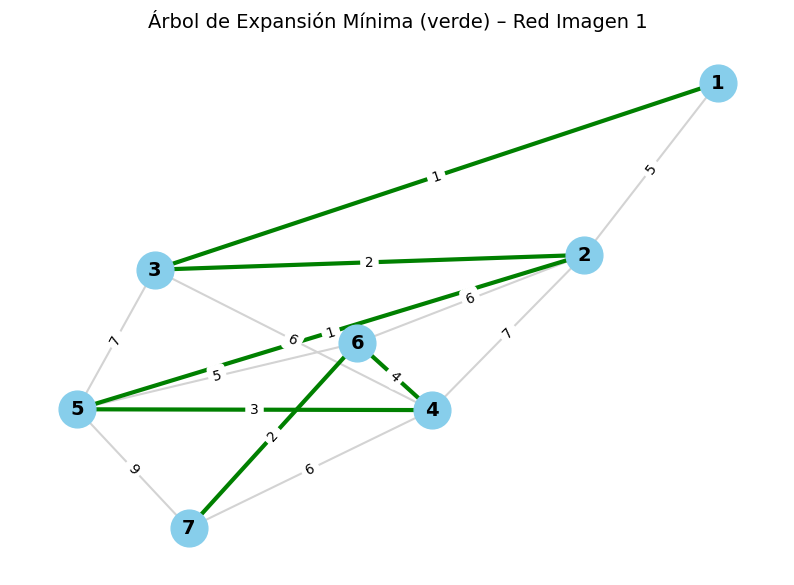

In [4]:
# ============================================================
# PASO 4: Visualizar el grafo y el MST
# ============================================================
# spring_layout asigna posiciones a los nodos usando un algoritmo 
# de resortes (nodos conectados se atraen). seed=42 fija la 
# aleatoriedad para reproducibilidad.
pos = nx.spring_layout(G1_und, seed=42)

plt.figure(figsize=(10, 7))

# Dibujamos TODAS las aristas originales en gris claro (fondo)
nx.draw_networkx_edges(G1_und, pos, edge_color='lightgray', width=1.5)

# Dibujamos SOLO las aristas del MST en verde grueso (encima)
nx.draw_networkx_edges(mst, pos, edge_color='green', width=3)

# Nodos como círculos azules con etiquetas
nx.draw_networkx_nodes(G1_und, pos, node_color='skyblue', node_size=700)
nx.draw_networkx_labels(G1_und, pos, font_size=14, font_weight='bold')

# Etiquetas de peso en cada arista
nx.draw_networkx_edge_labels(
    G1_und, pos,
    edge_labels={(u, v): d['weight'] for u, v, d in G1_und.edges(data=True)}
)

plt.title("Árbol de Expansión Mínima (verde) – Red Imagen 1", fontsize=14)
plt.axis('off')  # Quitamos los ejes x,y (no aportan nada)
plt.show()

## Ruta Más Corta (Dijkstra)

### Formulación matemática
---
Dado un grafo dirigido $G=(V,E)$ con pesos $w_{ij} \ge 0$, se busca el camino $P$ desde el origen $s$ hasta el destino $t$ que minimice:

$$\min \sum_{(i,j) \in P} w_{ij}$$

Diferencia clave con el MST: El MST conecta TODOS los nodos con costo mínimo; la ruta más corta solo encuentra el mejor camino entre DOS nodos específicos.

### Definición del grafo dirigido
---

In [5]:
# ============================================================
# PASO 1: Crear un grafo DIRIGIDO con los arcos originales
# ============================================================
# nx.DiGraph() crea un grafo dirigido (las aristas tienen dirección)
G1 = nx.DiGraph()

# add_weighted_edges_from() agrega muchas aristas de una vez
# Cada tupla (u, v, w) crea la arista u→v con atributo weight=w
G1.add_weighted_edges_from(edges_G1)

print("Nodos:", list(G1.nodes()))
print("Aristas:", list(G1.edges(data='weight')))

Nodos: [1, 2, 3, 6, 4, 5, 7]
Aristas: [(1, 2, 5), (1, 3, 1), (2, 3, 2), (2, 6, 6), (2, 4, 7), (2, 5, 1), (3, 4, 6), (3, 5, 7), (6, 2, 7), (6, 7, 2), (4, 3, 7), (4, 6, 4), (4, 7, 6), (4, 5, 3), (5, 6, 5), (5, 7, 9)]


### Cálculo con Dijkstra
---

In [6]:
# ============================================================
# PASO 2: Calcular la ruta más corta de 1 a 7
# ============================================================
origen, destino = 1, 7

# nx.shortest_path() devuelve la LISTA DE NODOS de la ruta óptima
# Parámetros:
#   - G: grafo (dirigido o no dirigido)
#   - source: nodo de origen
#   - target: nodo de destino
#   - weight: atributo con el peso ('weight' por defecto)
# Internamente usa DIJKSTRA si los pesos son no negativos.
ruta = nx.shortest_path(G1, source=origen, target=destino, weight='weight')

# nx.shortest_path_length() devuelve el COSTO TOTAL (suma de pesos)
longitud = nx.shortest_path_length(G1, source=origen, target=destino, weight='weight')

print(f"Ruta más corta de {origen} a {destino}: {ruta}")
print(f"Longitud total: {longitud}")

Ruta más corta de 1 a 7: [1, 3, 4, 7]
Longitud total: 13


Salida esperada:

```
Ruta más corta de 1 a 7: [1, 3, 4, 7]
Longitud total: 13
```

Por qué el camino 1→3→4→7? Porque $1+6+6=13$. Existe otra ruta óptima $1\to3\to4\to6\to7$ con $1+6+4+2=13$. Dijkstra devuelve una de las óptimas.

### Dibujo de la ruta más corta
---

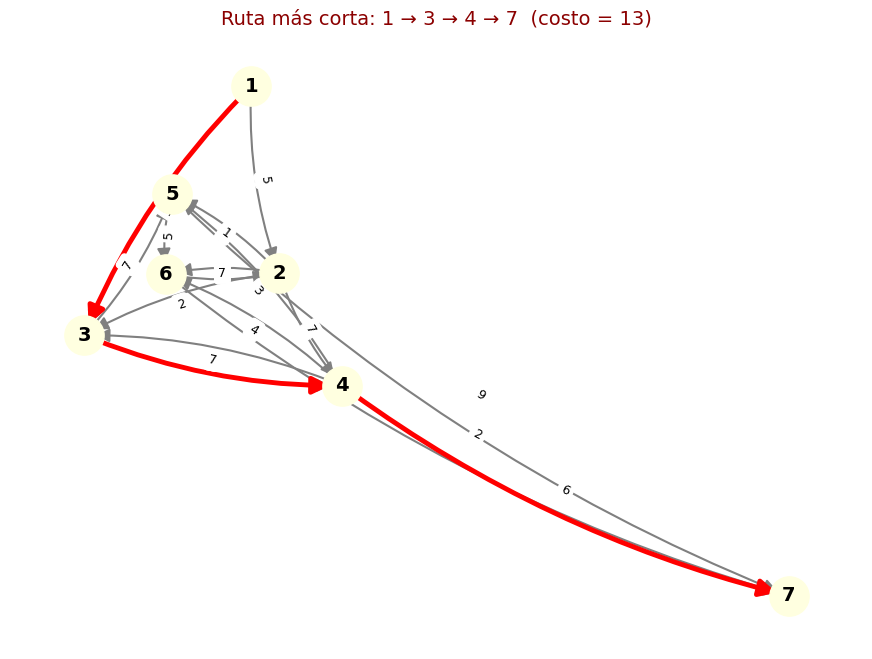

In [7]:
# ============================================================
# PASO 3: Visualizar la ruta más corta
# ============================================================
pos = nx.spring_layout(G1, seed=42)

plt.figure(figsize=(11, 8))

# Nodos y etiquetas
nx.draw_networkx_nodes(G1, pos, node_color='lightyellow', node_size=800)
nx.draw_networkx_labels(G1, pos, font_size=14, font_weight='bold')

# Todas las aristas en gris (fondo)
# connectionstyle='arc3,rad=0.1' curva ligeramente las flechas
# para que arcos opuestos no se superpongan
nx.draw_networkx_edges(G1, pos, edge_color='gray', width=1.5,
                       arrowsize=20, connectionstyle='arc3,rad=0.1')

# Convertimos la lista de nodos [1,3,4,7] en pares de aristas [(1,3),(3,4),(4,7)]
ruta_edges = list(zip(ruta[:-1], ruta[1:]))

# Resaltamos SOLO las aristas de la ruta en ROJO
nx.draw_networkx_edges(G1, pos, edgelist=ruta_edges,
                       edge_color='red', width=3.5,
                       arrowsize=25, connectionstyle='arc3,rad=0.1')

# Etiquetas con los pesos
nx.draw_networkx_edge_labels(
    G1, pos,
    edge_labels={(u, v): d['weight'] for u, v, d in G1.edges(data=True)},
    font_size=9
)

plt.title(f"Ruta más corta: {' → '.join(map(str, ruta))}  (costo = {longitud})",
          fontsize=14, color='darkred')
plt.axis('off')
plt.show()

## Flujo Máximo

### Formulación matemática
---
Dado un grafo dirigido $G=(V,E)$ con capacidades $c_{ij} \ge 0$, y nodos fuente $s$ y sumidero $t$, se busca maximizar el flujo $v$:

$$\max v \\

\text{sujeto a: }\\

\sum_{j:(i,j)\in E} f_{ij} - \sum_{j:(j,i)\in E} f_{ji} =
\begin{cases}
v & i = s \text{ (fuente)}\\
0 & i \neq s,t \text{ (conservación)}\\
-v & i = t \text{ (sumidero)}
\end{cases}

0 \le f_{ij} \le c_{ij} \quad \forall (i,j) \in E
$$
Interpretación: El flujo que sale de la fuente es $v$, se conserva en nodos intermedios y llega íntegro al sumidero. Ningún arco puede llevar más flujo que su capacidad.

### Definición del grafo
---

In [8]:
# ============================================================
# PASO 1: Definir la red de la Imagen 2
# ============================================================
# Cada tupla: (origen, destino, capacidad)
edges_G2 = [
    (1, 2, 8),  (1, 3, 14), (1, 5, 4),
    (2, 3, 5),  (2, 4, 7),  (2, 5, 6),
    (3, 4, 9),  (3, 5, 10),
    (4, 5, 5)
]

# Creamos un grafo DIRIGIDO (el flujo tiene dirección)
G2 = nx.DiGraph()

# Agregamos cada arco con su atributo 'capacity' (capacidad)
for u, v, c in edges_G2:
    G2.add_edge(u, v, capacity=c)

print("Nodos:", list(G2.nodes()))
print("Aristas con capacidad:")
for u, v, d in G2.edges(data=True):
    print(f"  {u} → {v}  (capacidad = {d['capacity']})")

Nodos: [1, 2, 3, 5, 4]
Aristas con capacidad:
  1 → 2  (capacidad = 8)
  1 → 3  (capacidad = 14)
  1 → 5  (capacidad = 4)
  2 → 3  (capacidad = 5)
  2 → 4  (capacidad = 7)
  2 → 5  (capacidad = 6)
  3 → 4  (capacidad = 9)
  3 → 5  (capacidad = 10)
  4 → 5  (capacidad = 5)


### Cálculo del flujo máximo
---

In [9]:
# ============================================================
# PASO 2: Calcular el flujo máximo de 1 a 5
# ============================================================
fuente, sumidero = 1, 5

# nx.maximum_flow() implementa el algoritmo de Edmonds-Karp
# (variante de Ford-Fulkerson con BFS).
# Devuelve DOS valores:
#   - flujo_max: valor total del flujo (número)
#   - flujo_dict: diccionario {u: {v: flujo_en_arco_u_v}}
flujo_max, flujo_dict = nx.maximum_flow(G2, fuente, sumidero)

print(f"Flujo máximo de {fuente} a {sumidero}: {flujo_max}")
print("Distribución del flujo:")
for u, vecinos in flujo_dict.items():
    for v, f in vecinos.items():
        # Solo mostramos arcos con flujo positivo
        if f > 0:
            print(f"  {u} → {v} : {f} / {G2[u][v]['capacity']}")

Flujo máximo de 1 a 5: 25
Distribución del flujo:
  1 → 2 : 8 / 8
  1 → 3 : 13 / 14
  1 → 5 : 4 / 4
  2 → 3 : 2 / 5
  2 → 5 : 6 / 6
  3 → 4 : 5 / 9
  3 → 5 : 10 / 10
  4 → 5 : 5 / 5


Salida esperada:

```
Flujo máximo de 1 a 5: 25
Distribución del flujo:
  1 → 2 : 8 / 8
  1 → 3 : 13 / 14
  1 → 5 : 4 / 4
  2 → 3 : 2 / 5
  2 → 5 : 6 / 6
  3 → 4 : 5 / 9
  3 → 5 : 10 / 10
  4 → 5 : 5 / 5
```

### Corte mínimo (teorema max-flow min-cut)
---

In [10]:
# ============================================================
# PASO 3: Verificar con el corte mínimo
# ============================================================
# El teorema de max-flow min-cut dice:
#   flujo máximo = capacidad del corte mínimo
# Un CORTE es una partición (S, T) con fuente en S y sumidero en T.
# La capacidad del corte es la suma de capacidades de arcos S→T.
corte_min, particion = nx.minimum_cut(G2, fuente, sumidero)
print(f"Capacidad del corte mínimo: {corte_min}")
print(f"Partición: {particion}")

Capacidad del corte mínimo: 25
Partición: ({1, 2, 3, 4}, {5})


### Dibujo del flujo máximo
---

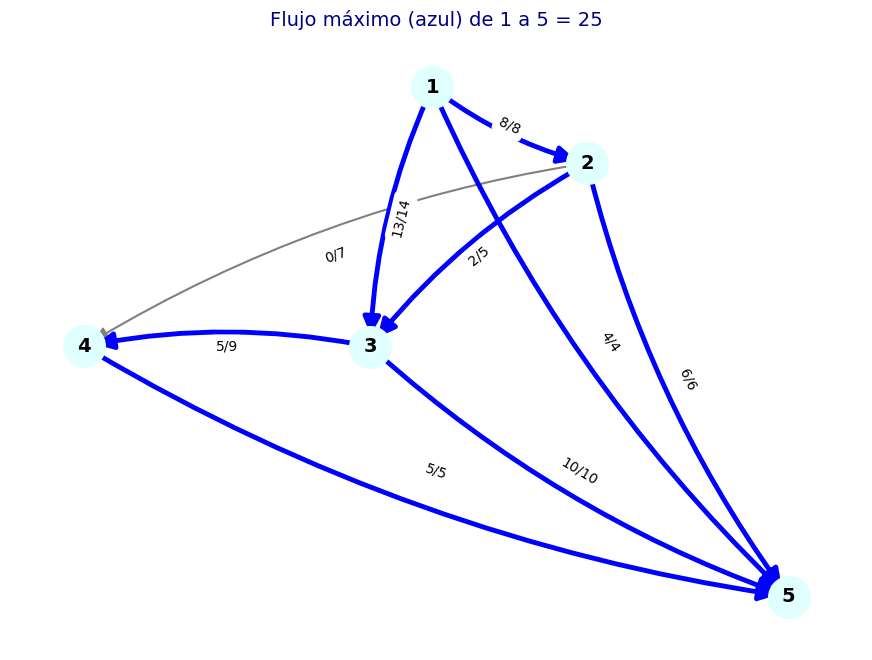

In [11]:
# ============================================================
# PASO 4: Visualizar el flujo sobre la red
# ============================================================
pos = nx.spring_layout(G2, seed=7)

plt.figure(figsize=(11, 8))

# Nodos y etiquetas
nx.draw_networkx_nodes(G2, pos, node_color='lightcyan', node_size=900)
nx.draw_networkx_labels(G2, pos, font_size=14, font_weight='bold')

# Todas las aristas en gris (fondo)
nx.draw_networkx_edges(G2, pos, edge_color='gray', width=1.5,
                       arrowsize=20, connectionstyle='arc3,rad=0.1')

# Identificamos las aristas que llevan flujo > 0
aristas_flujo = [
    (u, v)
    for u, vec in flujo_dict.items()   # recorremos cada nodo u y sus vecinos
    for v, f in vec.items()            # recorremos cada arco u→v con flujo f
    if f > 0                           # solo arcos con flujo positivo
]

# Las resaltamos en AZUL
nx.draw_networkx_edges(G2, pos, edgelist=aristas_flujo,
                       edge_color='blue', width=3.5,
                       arrowsize=25, connectionstyle='arc3,rad=0.1')

# Etiquetas: mostramos "flujo/capacidad" en cada arco
etiquetas = {}
for u, v, d in G2.edges(data=True):
    f = flujo_dict.get(u, {}).get(v, 0)  # flujo en u→v (0 si no aparece)
    etiquetas[(u, v)] = f"{f}/{d['capacity']}"
nx.draw_networkx_edge_labels(G2, pos, edge_labels=etiquetas, font_size=10)

plt.title(f"Flujo máximo (azul) de {fuente} a {sumidero} = {flujo_max}",
          fontsize=14, color='navy')
plt.axis('off')
plt.show()

## Documentación de funciones de NetworkX
---

Función Descripción Parámetros clave
nx.Graph() Crea grafo no dirigido —
nx.DiGraph() Crea grafo dirigido —
add_edge(u, v, **attr) Agrega arista con atributos weight, capacity
add_weighted_edges_from(lista) Agrega varias aristas con peso lista de tuplas (u,v,w)
G.has_edge(u, v) ¿Existe arista entre u y v? devuelve True/False
G.size(weight='weight') Suma de pesos de aristas —
G.edges(data=True) Itera aristas con atributos devuelve (u, v, dict)
nx.minimum_spanning_tree(G, algorithm) Calcula MST algorithm='kruskal' o 'prim'
nx.shortest_path(G, source, target, weight) Ruta más corta devuelve lista de nodos
nx.shortest_path_length(...) Longitud de la ruta devuelve número
nx.maximum_flow(G, s, t) Flujo máximo devuelve (valor, dict)
nx.minimum_cut(G, s, t) Corte mínimo devuelve (capacidad, partición)
nx.spring_layout(G, seed) Posiciones para dibujar seed para reproducibilidad
nx.draw_networkx_nodes(...) Dibuja nodos node_color, node_size
nx.draw_networkx_edges(...) Dibuja aristas edgelist, edge_color, width
nx.draw_networkx_edge_labels(...) Etiquetas en aristas edge_labels (dict)

## Resumen de soluciones
---
Problema Red Solución óptima Valor
MST Imagen 1 (no dirigida) Aristas: (1,3), (2,5), (2,3), (6,7), (4,5), (4,6) 13
Ruta más corta Imagen 1 (dirigida) $1 \to 3 \to 4 \to 7$ 13
Flujo máximo Imagen 2 Distribución mostrada en §4.3 25


## Conclusión y buenas prácticas
---
Flujo típico de trabajo en NetworkX:

1. Elegir el tipo de grafo: Graph() para no dirigido, DiGraph() para dirigido.
2. Cargar los datos: con add_edge, add_weighted_edges_from o desde archivos.
3. Asignar atributos: weight para rutas/MST, capacity para flujo.
4. Llamar al algoritmo: una sola línea resuelve el problema.
5. Visualizar: spring_layout + funciones *draw_* para validar.